# Practical 10 — Iris Analysis (Lean)
Histograms, boxplots and simple outlier counts for the Iris dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
# load Iris from Prac10 folder
df = pd.read_csv('../Prac10/Iris.csv')
df = df.drop(columns=['Id'], errors='ignore')
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [2]:
# Quick summary
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


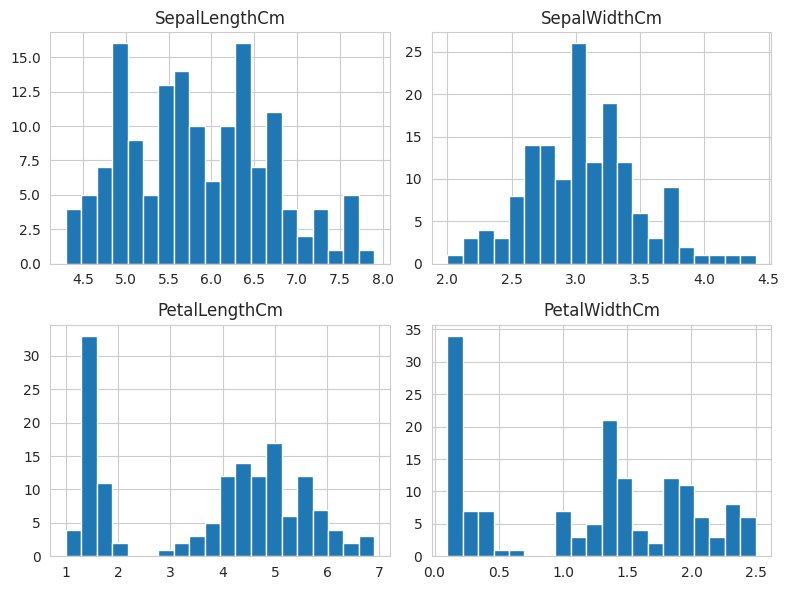

In [3]:
# Histograms for numeric features
numeric = df.select_dtypes(include=['number']).columns.tolist()
df[numeric].hist(figsize=(8,6), bins=20)
plt.tight_layout()
plt.show()

SepalLengthCm: 0 outliers
SepalWidthCm: 4 outliers
PetalLengthCm: 0 outliers
PetalWidthCm: 0 outliers


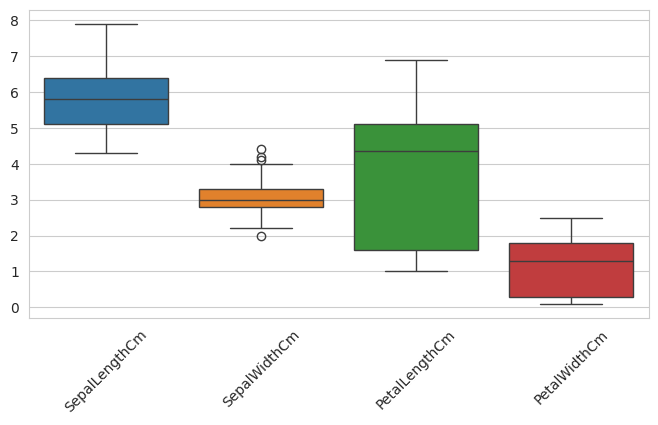

In [4]:
# Boxplots and IQR-based outlier counts
import numpy as np
for col in numeric:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lb = q1 - 1.5 * iqr
    ub = q3 + 1.5 * iqr
    n_out = df[(df[col] < lb) | (df[col] > ub)].shape[0]
    print(f'{col}: {n_out} outliers')

plt.figure(figsize=(8,4))
sns.boxplot(data=df[numeric])
plt.xticks(rotation=45)
plt.show()